In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.signal import periodogram

**Colour coding:** regions are consistently coloured throughout — Dublin and North East `#1f77b4`, Dublin and Midlands `#ff7f0e`, Dublin and South East `#2ca02c`, West and North West `#d62728`, South West `#9467bd`, Mid West `#8c564b`.

In [17]:
df = pd.read_csv("../data/raw data/weekly_by_region_202604082051.csv")
df["week_start"] = pd.to_datetime(df["week_start"])
df = df[df["days_in_week"] == 7].copy()

REGION = "HSE Dublin and Midlands"
series = df[df["region"] == REGION].sort_values("week_start")["total_trolleys"].reset_index(drop=True)
print(f"{REGION}: {len(series)} weeks")

HSE Dublin and Midlands: 170 weeks


## ACF

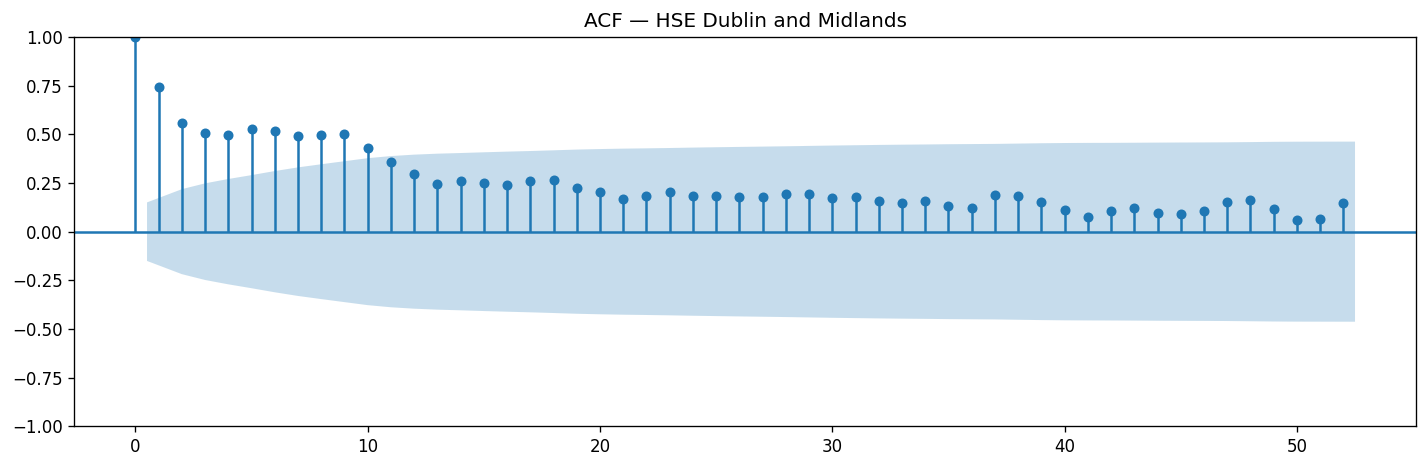

In [18]:
fig, ax = plt.subplots(figsize=(12, 4), dpi=120)
plot_acf(series, lags=52, ax=ax, title=f"ACF — {REGION}")
plt.tight_layout()
plt.show()

## PACF

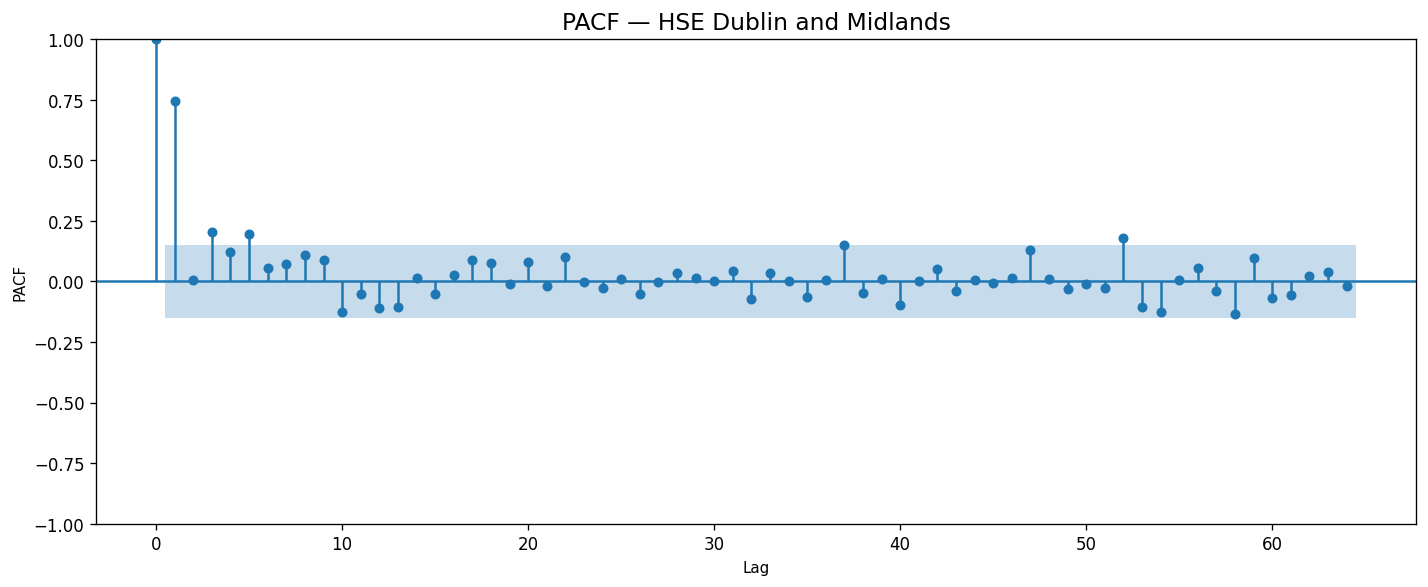

In [19]:
fig, ax = plt.subplots(figsize=(12, 5), dpi=120)
plot_pacf(series, lags=list(range(65)), ax=ax)
plt.title(f"PACF — {REGION}", fontsize=14)
plt.xlabel("Lag", fontsize=9)
plt.ylabel("PACF", fontsize=9)
plt.tight_layout()
plt.show()

## PSD

/var/folders/8p/bnwtr4b93fn3_th1x9ysmwy00000gn/T/ipykernel_28682/581960603.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


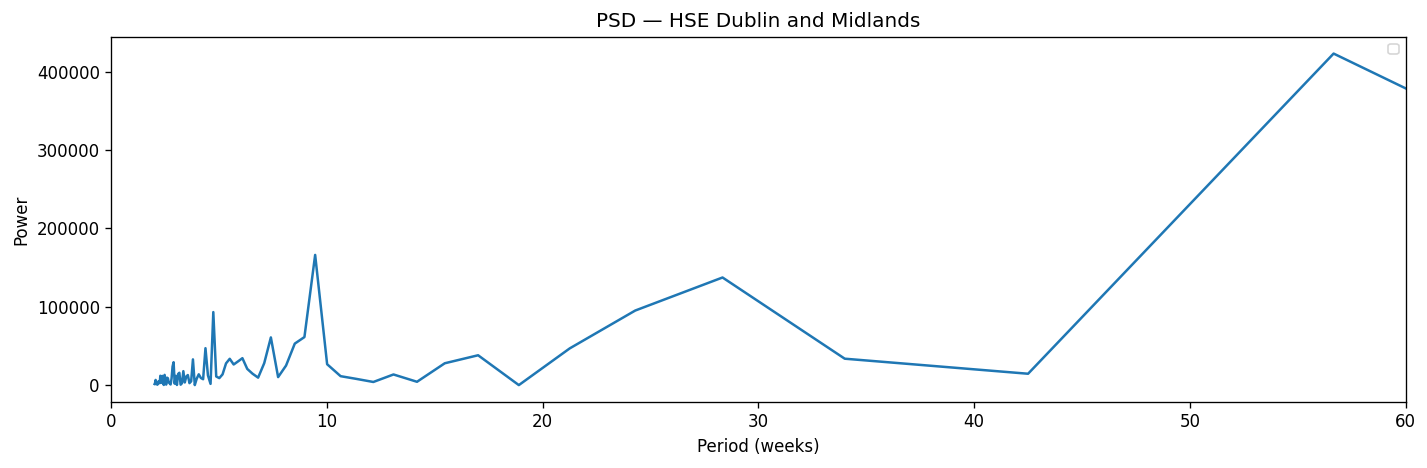

In [20]:
fig, ax = plt.subplots(figsize=(12, 4), dpi=120)
freqs, power = periodogram(series.dropna(), fs=1.0, detrend="linear")
periods = 1 / freqs[1:]
ax.plot(periods, power[1:])
ax.set_xlabel("Period (weeks)")
ax.set_ylabel("Power")
ax.set_title(f"PSD — {REGION}")
ax.set_xlim(0, 60)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## PSD — all regions

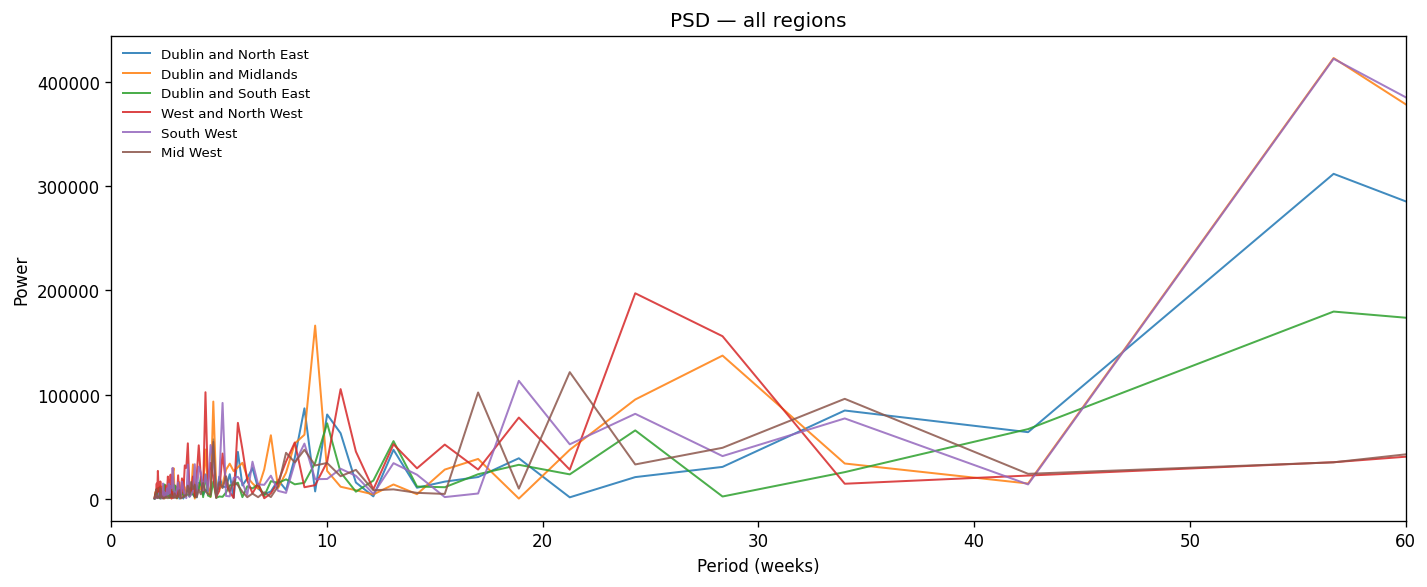

In [21]:
REGION_COLOR = {
    "HSE Dublin and North East": "#1f77b4",
    "HSE Dublin and Midlands":   "#ff7f0e",
    "HSE Dublin and South East": "#2ca02c",
    "HSE West and North West":   "#d62728",
    "HSE South West":            "#9467bd",
    "HSE Mid West":              "#8c564b",
}

fig, ax = plt.subplots(figsize=(12, 5), dpi=120)

for region, color in REGION_COLOR.items():
    s = df[df["region"] == region].sort_values("week_start")["total_trolleys"].dropna()
    freqs, power = periodogram(s, fs=1.0, detrend="linear")
    periods = 1 / freqs[1:]
    ax.plot(periods, power[1:], color=color, linewidth=1.2, alpha=0.85, label=region.replace("HSE ", ""))

ax.set_xlim(0, 60)
ax.set_xlabel("Period (weeks)")
ax.set_ylabel("Power")
ax.set_title("PSD — all regions")
ax.legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

## New Year traces

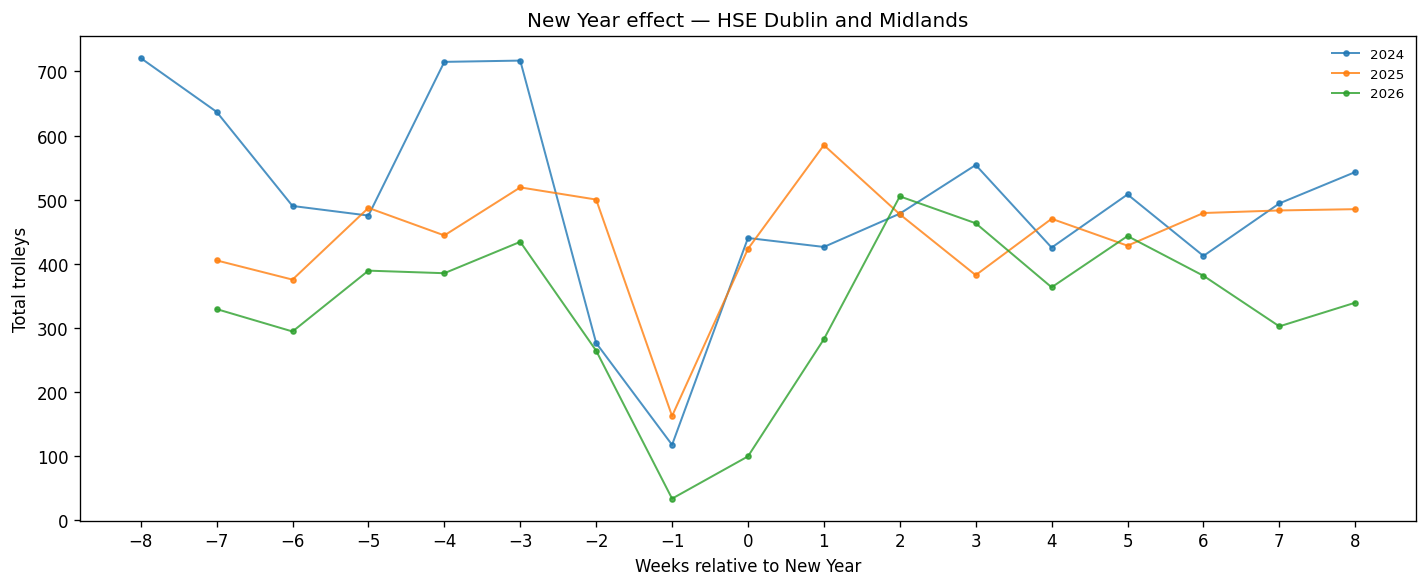

In [22]:
import numpy as np

WINDOW = 8  # weeks either side of new year

full = df[df["region"] == REGION].sort_values("week_start").copy()

traces = {}
for year in sorted(full["week_start"].dt.year.unique()):
    ny = pd.Timestamp(f"{year}-01-01")
    mask = (
        (full["week_start"] >= ny - pd.Timedelta(weeks=WINDOW)) &
        (full["week_start"] <= ny + pd.Timedelta(weeks=WINDOW))
    )
    subset = full[mask].copy()
    if len(subset) == 0:
        continue
    subset["rel_week"] = ((subset["week_start"] - ny).dt.days / 7).round().astype(int)
    traces[year] = subset.set_index("rel_week")["total_trolleys"]

fig, ax = plt.subplots(figsize=(12, 5), dpi=120)

for year, trace in traces.items():
    if year != 2023:  # skip 2023 for now since it's incomplete
        ax.plot(trace.sort_index().index, trace.sort_index().values, alpha=0.8, linewidth=1.2,
                marker="o", markersize=3, label=str(year))

# mean_trace = pd.concat(traces.values(), axis=1).mean(axis=1).sort_index()
# ax.plot(mean_trace.index, mean_trace.values,
#         color="black", linewidth=2.5, marker="o", markersize=5, label="Mean", zorder=5)

ax.set_xticks(range(-WINDOW, WINDOW + 1))
ax.set_xlabel("Weeks relative to New Year")
ax.set_ylabel("Total trolleys")
ax.set_title(f"New Year effect — {REGION}")
ax.legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

## Mid West reset (Aug 2024)

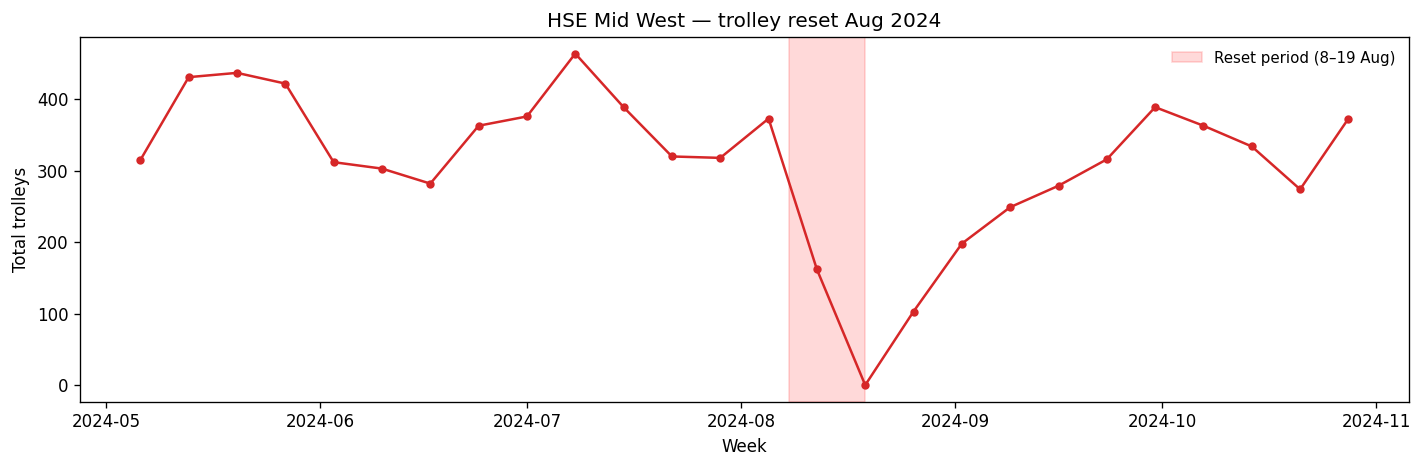

In [23]:
mw = df[df["region"] == "HSE Mid West"].sort_values("week_start").copy()

# Show context window around the reset
mask = (mw["week_start"] >= "2024-05-01") & (mw["week_start"] <= "2024-11-01")
mw_window = mw[mask]

fig, ax = plt.subplots(figsize=(12, 4), dpi=120)

ax.plot(mw_window["week_start"], mw_window["total_trolleys"],
        marker="o", linewidth=1.5, markersize=4, color="#d62728")

# Shade the reset period
ax.axvspan(pd.Timestamp("2024-08-08"), pd.Timestamp("2024-08-19"),
           alpha=0.15, color="red", label="Reset period (8–19 Aug)")

ax.set_xlabel("Week")
ax.set_ylabel("Total trolleys")
ax.set_title("HSE Mid West — trolley reset Aug 2024")
ax.legend(fontsize=9, frameon=False)
plt.tight_layout()
plt.show()

## Mean component (per 10k)

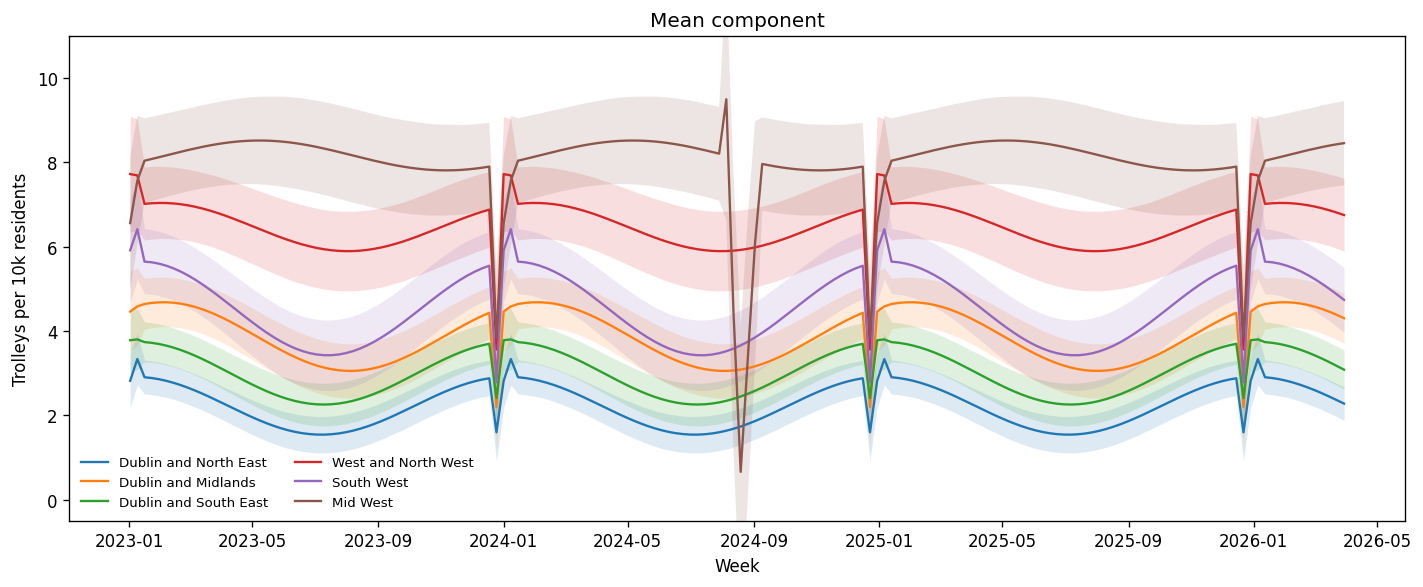

In [24]:
MODEL_DIR = "../data/models/wide_weekly_scaledPer10k/v2.6"
INPUT_CSV = "../data/wide_weekly_scaledPer10k.csv"

mu = pd.read_csv(f"{MODEL_DIR}/mu.csv")
mu_lo = pd.read_csv(f"{MODEL_DIR}/mu_lower.csv")
mu_hi = pd.read_csv(f"{MODEL_DIR}/mu_upper.csv")

dates = pd.to_datetime(pd.read_csv(INPUT_CSV, nrows=0).columns[1:])
assert len(dates) == len(mu), f"date/mu length mismatch: {len(dates)} vs {len(mu)}"

fig, ax = plt.subplots(figsize=(12, 5), dpi=120)

for region, color in REGION_COLOR.items():
    ax.fill_between(dates, mu_lo[region], mu_hi[region], color=color, alpha=0.15, linewidth=0)
    ax.plot(dates, mu[region], color=color, linewidth=1.4, label=region.replace("HSE ", ""))

ax.set_xlabel("Week")
ax.set_ylabel("Trolleys per 10k residents")
ax.set_title("Mean component")
ax.legend(fontsize=8, frameon=False, ncol=2)

plt.ylim(-0.5, 11)
plt.tight_layout()
plt.show()

## Normality diagnostics — innovations, not raw rates

The v2.6 likelihood is `y[i,t] ~ Normal(fullmod[i,t], 1/tau[i])`, so the normality assumption applies to the **innovation residuals** `y - fullmod` after the AR(1) correction — not the raw rates. The raw rates absorb the cycle, New Year shock, 5-week MW reset and regional level via `mu`, so they will not look normal and are not expected to.

Two checks below:

- **PPC density overlay**: simulate `y_rep` from 200 posterior draws and compare its distribution to observed `y`. If the model is well-specified, observed lies within the band of replicates.
- **QQ of standardised innovations**: `z[i,t] = (y - fullmod) * sqrt(tau_i)` should sit on the N(0,1) diagonal.

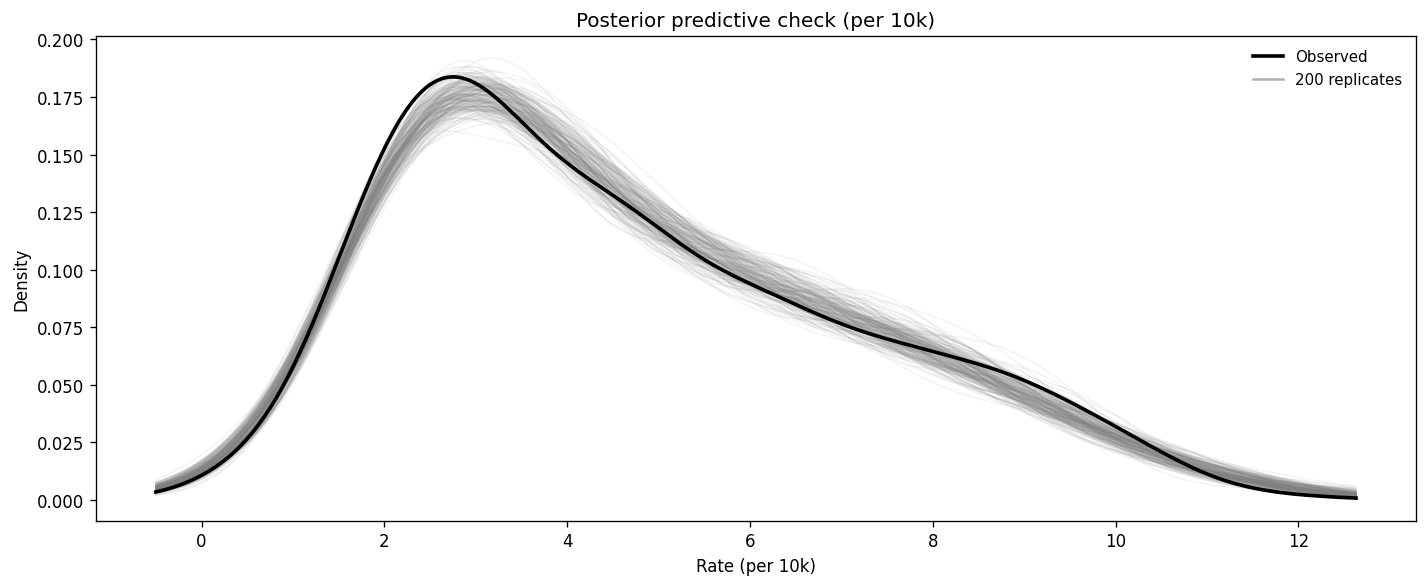

In [25]:
# PPC density overlay — observed y vs y_rep from 200 posterior draws
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

rng = np.random.default_rng(42)

# read in posterior samples from the fitted model
# so basically the paramters x gibbs samples
samples     = pd.read_csv(f"{MODEL_DIR}/raw_samples.csv")
# read in the rate data which is used to train model
y_df        = pd.read_csv(INPUT_CSV)
regions_ord = y_df["Region"].tolist()
# drop the region column
y_obs       = y_df.drop(columns="Region").values  # (I, T)
# get dimensions of observed values
I, T        = y_obs.shape

# make vector 1,2,3....n to help build indicators
t_vec = np.arange(1, T + 1)
# new year inidcator
week_mod = t_vec % 52
ny_pre  = (week_mod == 0).astype(float)
ny_mid  = (week_mod == 1).astype(float)
ny_post = (week_mod == 2).astype(float)

# reset indicator
fr3 = np.stack([(t_vec == t0).astype(float) for t0 in (84, 85, 86, 87, 88)])  # (5, T)
mw_ind  = np.array([1.0 if r == "HSE Mid West" else 0.0 for r in regions_ord])

# make the annual cycle terms
cos_t = np.cos(2 * np.pi * t_vec / 52)
sin_t = np.sin(2 * np.pi * t_vec / 52)

# draw 200 samples between 0 and len(samples)
draws = samples.iloc[rng.choice(len(samples), size=200, replace=False)].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 5), dpi=120)
x_grid = np.linspace(y_obs.min() - 0.5, y_obs.max() + 0.5, 400)

# for each draw
for k in range(len(draws)):
    # retrieve parameter values for this draw
    row = draws.iloc[k]
    # extract each parameter for each region
    a   = np.array([row[f"alpha[{i+1}]"]      for i in range(I)])
    b   = np.array([row[f"beta[{i+1}]"]       for i in range(I)])
    g   = np.array([row[f"gamma[{i+1}]"]      for i in range(I)])
    dpr = np.array([row[f"delta_pre[{i+1}]"]  for i in range(I)])
    dmd = np.array([row[f"delta_mid[{i+1}]"]  for i in range(I)])
    dpo = np.array([row[f"delta_post[{i+1}]"] for i in range(I)])
    tau = np.array([row[f"tau[{i+1}]"]        for i in range(I)])
    # global
    phi = row["phi"]    
    psi_w = np.array([row[f"psi_w{j+1}"] for j in range(5)])  # (5,)

    mw_term = (psi_w[:, None] * fr3).sum(axis=0)  # (T,)
    mu = (a[:, None]
          + b[:, None] * cos_t[None, :]
          + g[:, None] * sin_t[None, :]
          + dpr[:, None] * ny_pre[None, :]
          + dmd[:, None] * ny_mid[None, :]
          + dpo[:, None] * ny_post[None, :]
          + mw_ind[:, None] * mw_term[None, :])
    # stick first value of mu in along with res
    fullmod = mu.copy()
    # then for each folowing 
    fullmod[:, 1:] = mu[:, 1:] + phi * (y_obs[:, :-1] - mu[:, :-1])
    # add noise to get y_rep
    sigma_i = 1.0 / np.sqrt(tau)
    y_rep = fullmod + rng.normal(size=fullmod.shape) * sigma_i[:, None]
    ax.plot(x_grid, gaussian_kde(y_rep.ravel())(x_grid),
            color="grey", alpha=0.10, linewidth=0.8)

ax.plot(x_grid, gaussian_kde(y_obs.ravel())(x_grid),
        color="black", linewidth=2.2, label="Observed")
ax.plot([], [], color="grey", alpha=0.6, linewidth=1.5, label="200 replicates")
ax.set_xlabel("Rate (per 10k)")
ax.set_ylabel("Density")
ax.set_title("Posterior predictive check (per 10k)")
ax.legend(fontsize=9, frameon=False)
plt.tight_layout()
plt.show()

## Innovation residuals — QQ vs Normal(0, 1)

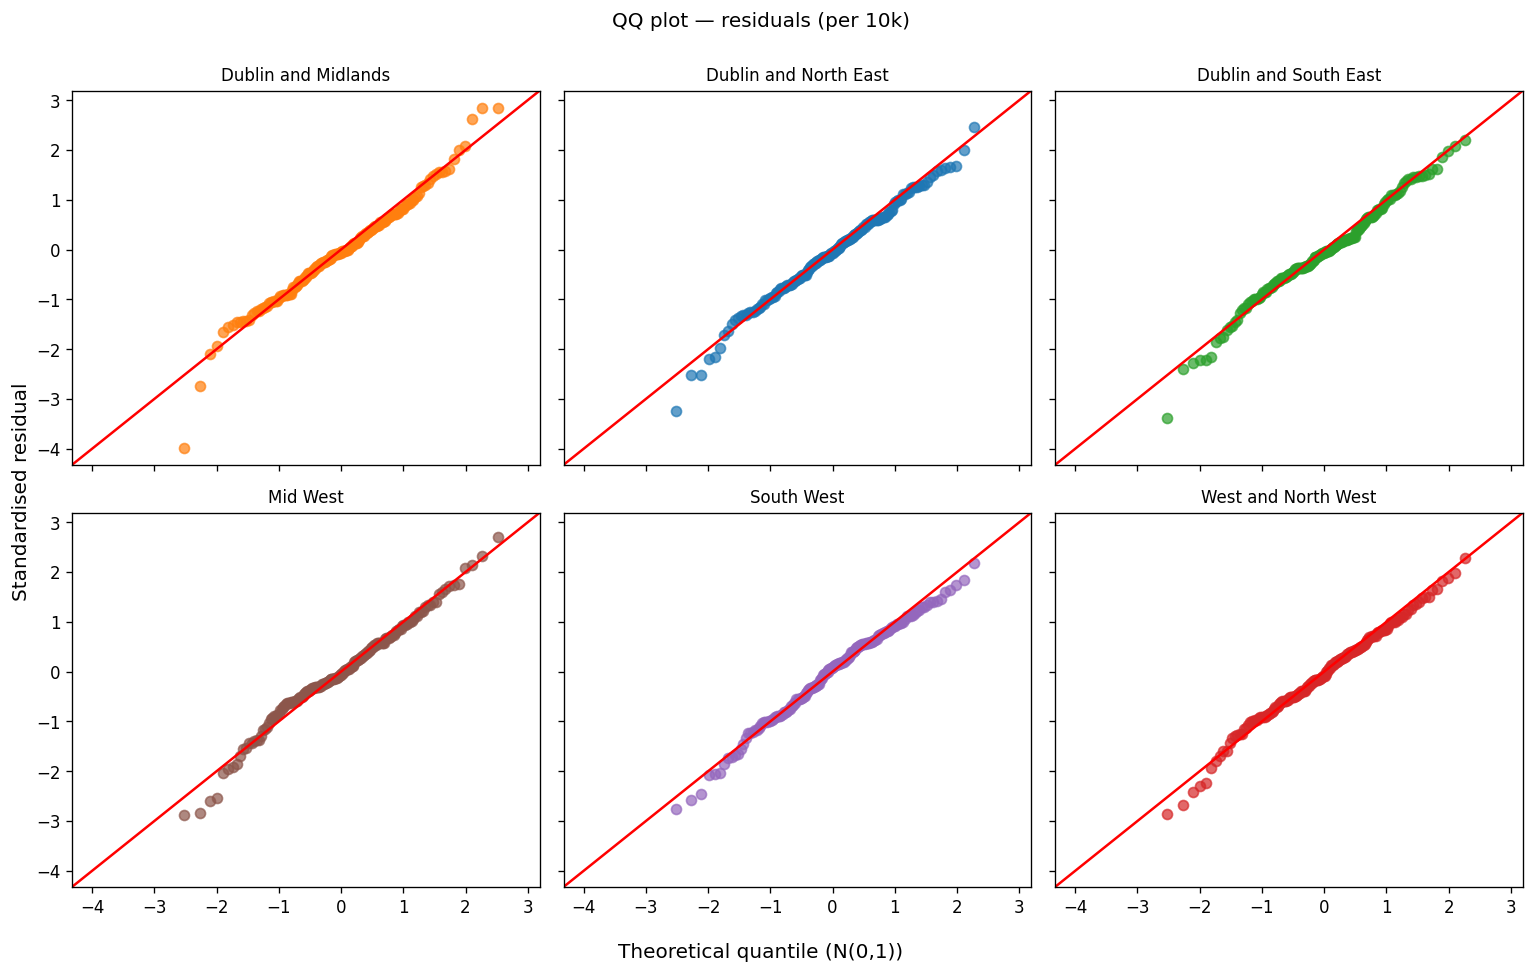

In [26]:
# Standardised innovation residuals vs N(0,1) — one panel per region
import statsmodels.api as sm

resid    = pd.read_csv(f"{MODEL_DIR}/residuals_posterior_mean.csv")
tau_mean = np.array([samples[f"tau[{i+1}]"].mean() for i in range(len(regions_ord))])

fig, axes = plt.subplots(2, 3, figsize=(13, 8), dpi=120, sharex=True, sharey=True)
for i, (region, ax) in enumerate(zip(regions_ord, axes.flat)):
    z = resid[region].values * np.sqrt(tau_mean[i])
    sm.qqplot(z, line="45", ax=ax,
              marker="o", markerfacecolor=REGION_COLOR[region],
              markeredgecolor=REGION_COLOR[region], alpha=0.7)
    ax.set_title(region.replace("HSE ", ""), fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.supxlabel("Theoretical quantile (N(0,1))")
fig.supylabel("Standardised residual")
fig.suptitle("QQ plot — residuals (per 10k)", y=1.0)
plt.tight_layout()
plt.show()

## Per-region histogram — standardised innovations

Per-region standardised innovations `z = (y - fullmod) * sqrt(tau_i)` against the N(0, 1) reference. Each panel shares axes so deviations from the black curve are directly comparable across regions.

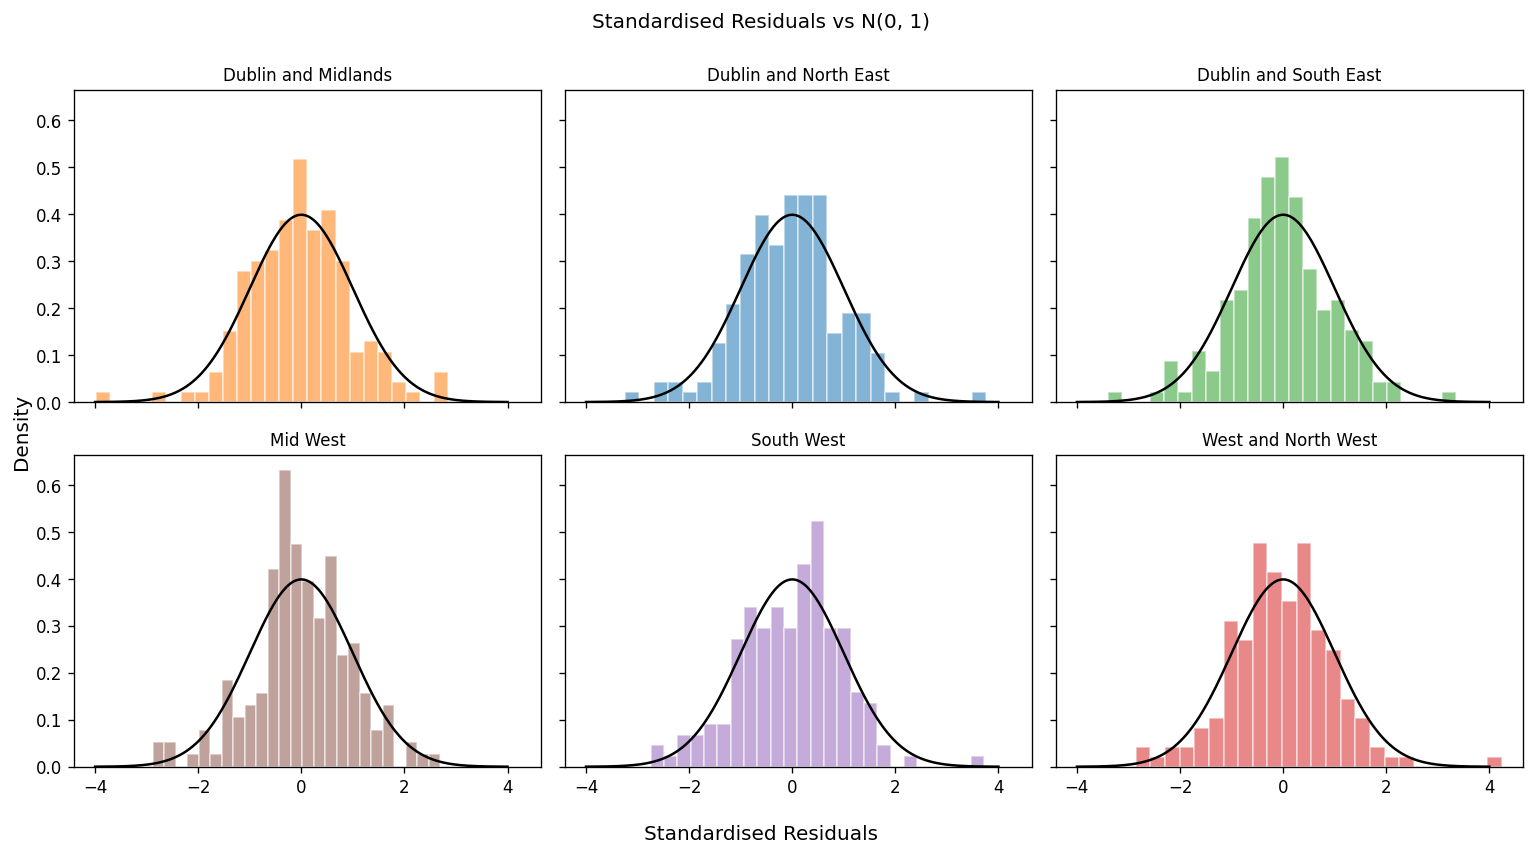

In [27]:
# Standardised innovations vs N(0, 1) — one panel per region
from scipy.stats import norm

x = np.linspace(-4, 4, 400)
fig, axes = plt.subplots(2, 3, figsize=(13, 7), dpi=120, sharex=True, sharey=True)
for i, (region, ax) in enumerate(zip(regions_ord, axes.flat)):
    z = resid[region].values * np.sqrt(tau_mean[i])
    ax.hist(z, bins=25, density=True, color=REGION_COLOR[region],
            alpha=0.55, edgecolor="white")
    ax.plot(x, norm.pdf(x), color="black", linewidth=1.5)
    ax.set_title(region.replace("HSE ", ""), fontsize=10)

fig.supxlabel("Standardised Residuals")
fig.supylabel("Density")
fig.suptitle("Standardised Residuals vs N(0, 1)", y=1.0)
plt.tight_layout()
plt.show()

## Residual ACF, PACF and PSD

Residual diagnostics on the innovation residuals `y - fullmod` (posterior mean), per region. If the v2.6 specification has absorbed the cycle, New Year shock, MW reset and AR(1) carry-over, residuals should look like white noise: ACF/PACF inside the 95% bands and a flat PSD.

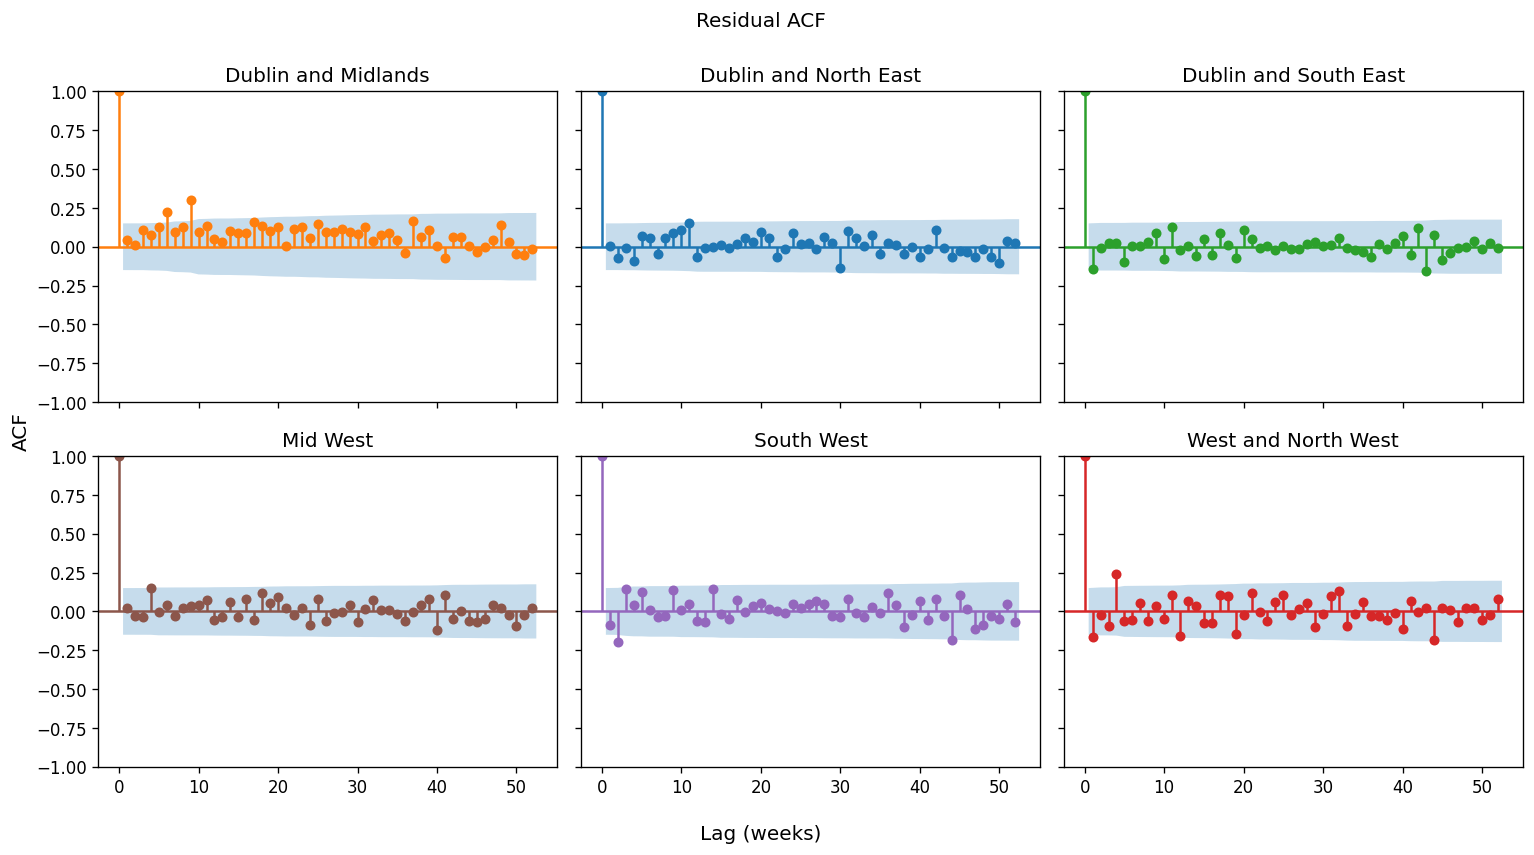

In [28]:
# Residual ACF — one panel per region
fig, axes = plt.subplots(2, 3, figsize=(13, 7), dpi=120, sharex=True, sharey=True)
for region, ax in zip(regions_ord, axes.flat):
    r = resid[region].dropna().values
    plot_acf(r, lags=52, ax=ax, title=region.replace("HSE ", ""),
             color=REGION_COLOR[region], vlines_kwargs={"colors": REGION_COLOR[region]})
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.supxlabel("Lag (weeks)")
fig.supylabel("ACF")
fig.suptitle("Residual ACF", y=1.0)
plt.tight_layout()
plt.show()

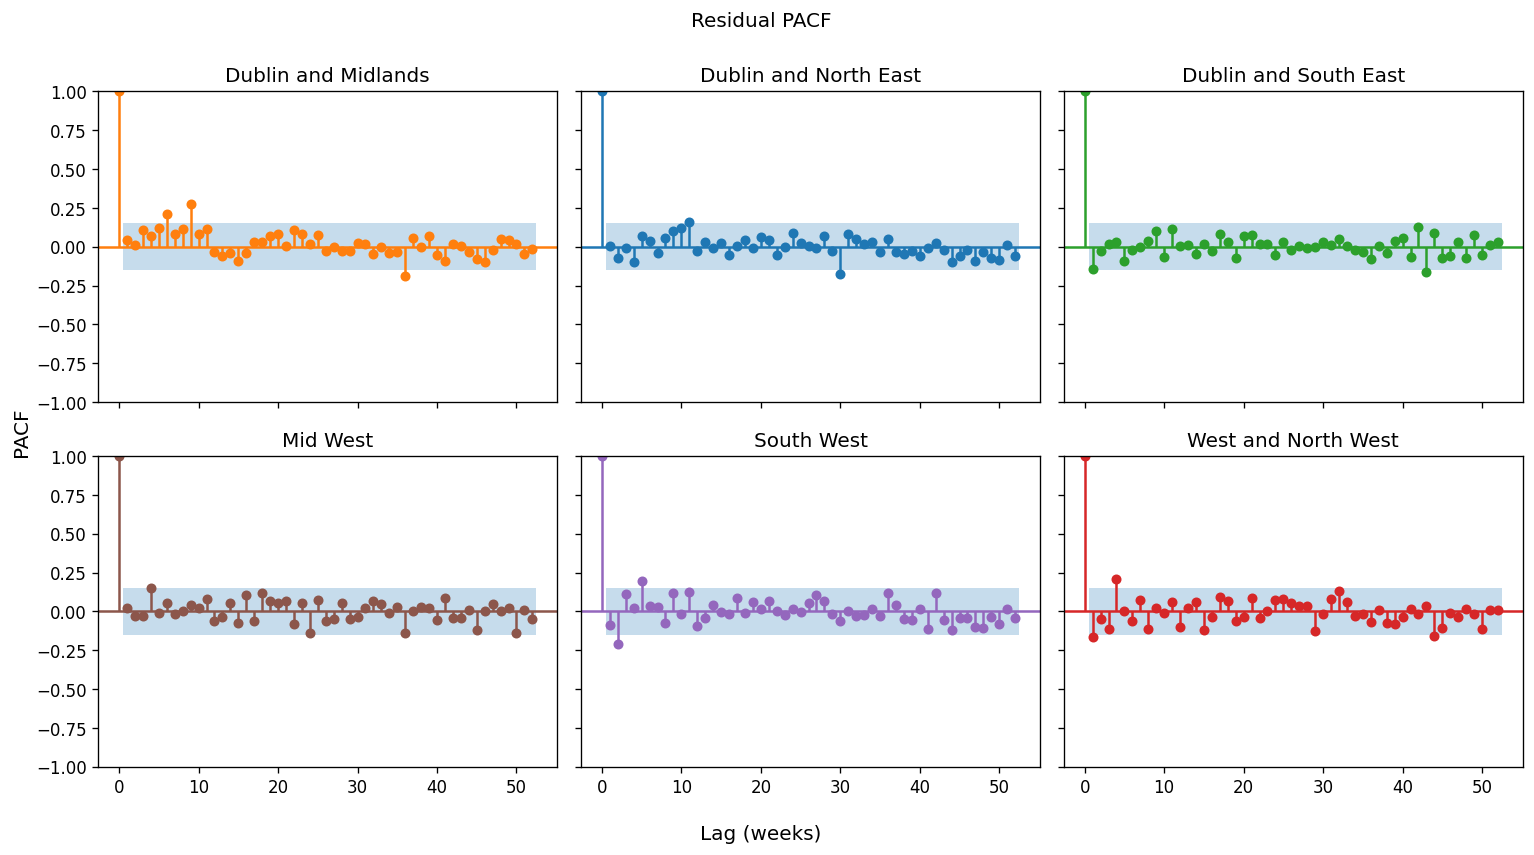

In [29]:
# Residual PACF — one panel per region
fig, axes = plt.subplots(2, 3, figsize=(13, 7), dpi=120, sharex=True, sharey=True)
for region, ax in zip(regions_ord, axes.flat):
    r = resid[region].dropna().values
    plot_pacf(r, lags=52, ax=ax, title=region.replace("HSE ", ""),
              color=REGION_COLOR[region], vlines_kwargs={"colors": REGION_COLOR[region]})
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.supxlabel("Lag (weeks)")
fig.supylabel("PACF")
fig.suptitle("Residual PACF", y=1.0)
plt.tight_layout()
plt.show()

In [30]:
# Significant residual PACF lags — |PACF| outside 95% white-noise band (±1.96/sqrt(N))
from statsmodels.tsa.stattools import pacf

rows = []
for region in regions_ord:
    r = resid[region].dropna().values
    n = len(r)
    band = 1.96 / np.sqrt(n)
    vals = pacf(r, nlags=52, method="ywm")
    for lag in range(1, len(vals)):  # skip lag 0
        if abs(vals[lag]) > band:
            rows.append({
                "region": region.replace("HSE ", ""),
                "lag": lag,
                "PACF": round(float(vals[lag]), 3),
                "95% band": round(float(band), 3),
            })

sig_pacf = pd.DataFrame(rows)
print(f"Significant residual PACF lags (|PACF| > 1.96/sqrt(N), N={n}, band=±{band:.3f})")
sig_pacf

Significant residual PACF lags (|PACF| > 1.96/sqrt(N), N=170, band=±0.150)


,region,lag,PACF,95% band
0,Dublin and Midlands,6,0.210,0.15
1,Dublin and Midlands,9,0.278,0.15
2,Dublin and Midlands,36,-0.186,0.15
3,Dublin and North East,11,0.162,0.15
4,Dublin and North East,30,-0.174,0.15
5,Dublin and South East,43,-0.163,0.15
6,South West,2,-0.210,0.15
7,South West,5,0.193,0.15
8,West and North West,1,-0.166,0.15
9,West and North West,4,0.210,0.15


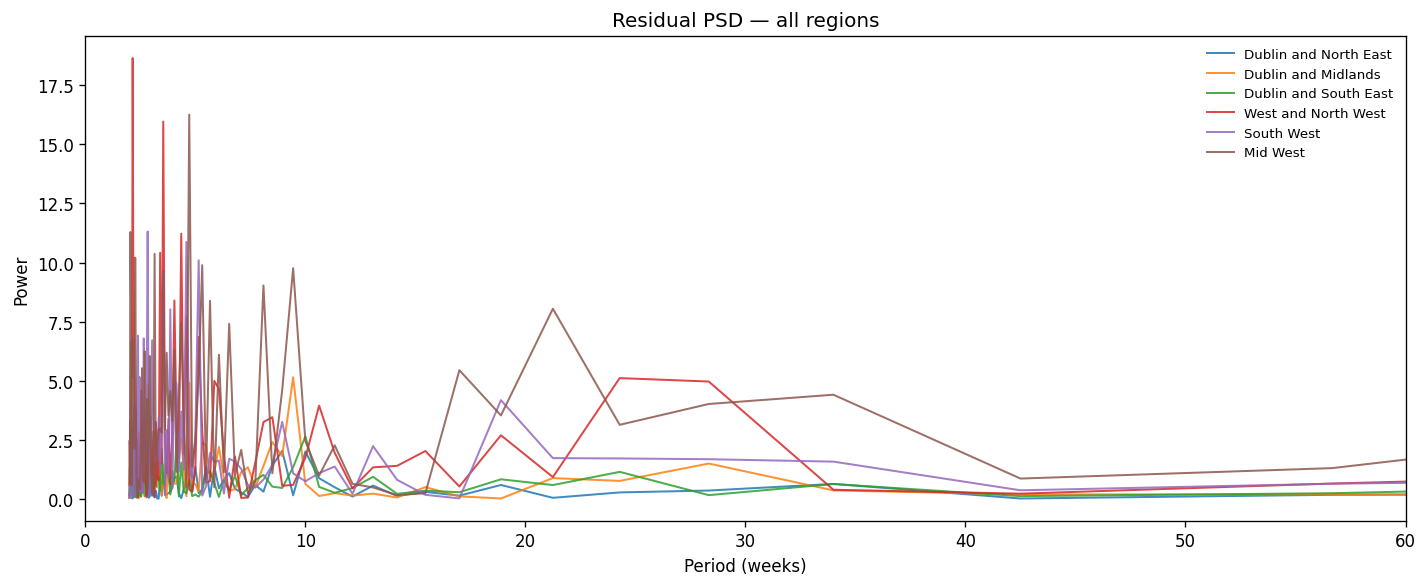

In [31]:
# Residual PSD — all regions overlaid
fig, ax = plt.subplots(figsize=(12, 5), dpi=120)

for region, color in REGION_COLOR.items():
    r = resid[region].dropna().values
    freqs, power = periodogram(r, fs=1.0, detrend="linear")
    periods = 1 / freqs[1:]
    ax.plot(periods, power[1:], color=color, linewidth=1.2, alpha=0.85,
            label=region.replace("HSE ", ""))

ax.set_xlim(0, 60)
ax.set_xlabel("Period (weeks)")
ax.set_ylabel("Power")
ax.set_title("Residual PSD — all regions")
ax.legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

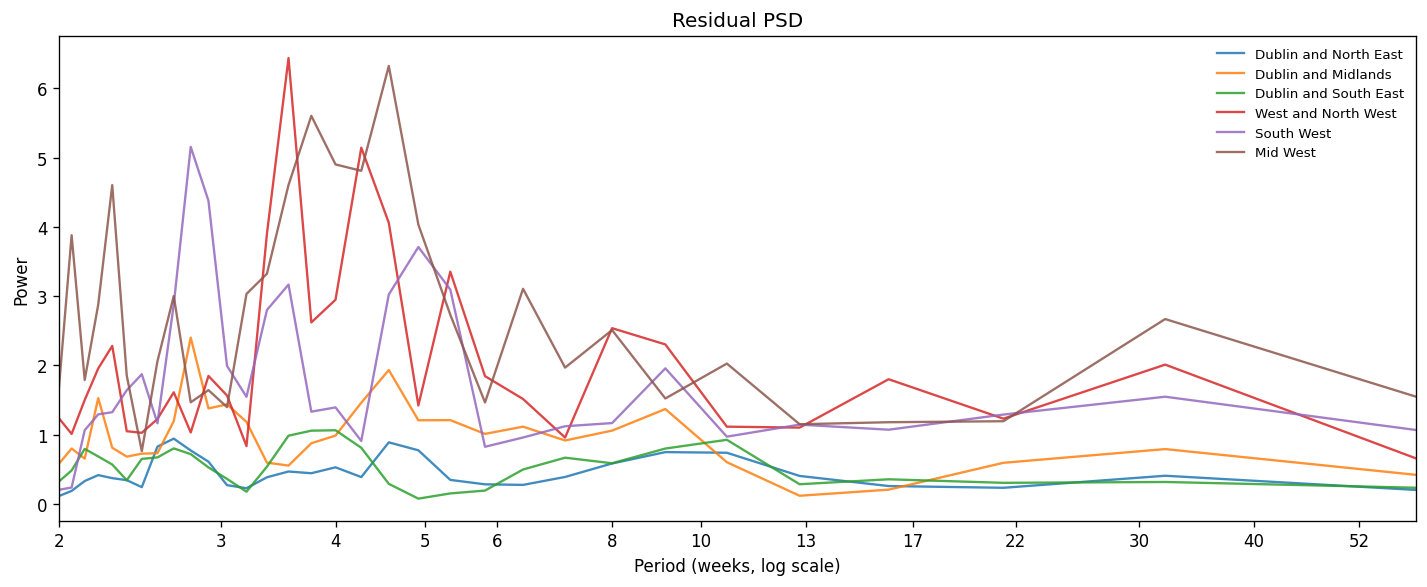

In [36]:
# Welch PSD of residuals — Hann window, 50% overlap, smoother spectral estimate
from scipy.signal import welch
from matplotlib.ticker import FixedLocator, FixedFormatter

NPERSEG = 64  # ~N/2.6 with N=170; Hann window, 50% overlap by default

fig, ax = plt.subplots(figsize=(12, 5), dpi=120)

for region, color in REGION_COLOR.items():
    r = resid[region].dropna().values
    freqs, power = welch(r, fs=1.0, nperseg=NPERSEG, detrend="linear")
    periods = 1 / freqs[1:]
    ax.plot(periods, power[1:], color=color, linewidth=1.4, alpha=0.85,
            label=region.replace("HSE ", ""))

ax.set_xscale("log")
ax.set_xlim(2, 60)

xticks = [2, 3, 4, 5, 6, 8, 10, 13, 17, 22, 30, 40, 52]
ax.xaxis.set_major_locator(FixedLocator(xticks))
ax.xaxis.set_major_formatter(FixedFormatter([str(t) for t in xticks]))
ax.xaxis.set_minor_locator(FixedLocator([]))

ax.set_xlabel("Period (weeks, log scale)")
ax.set_ylabel("Power")
ax.set_title(f"Residual PSD")
ax.legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()